# CAMELS three-dimensional fields: from volume visualization to Lyα forest synthesis

This notebook develops a continuous analysis of the downloaded CAMELS Multifield Dataset (CMD) grids. Part I establishes how the three-dimensional arrays are stored and visualizes representative slices from multiple simulations. Part II then constructs a one-dimensional sightline (or skewer), introduces the Voigt profile, extracts the physical fields required for Lyα absorption, and synthesizes a transmitted-flux spectrum.

The presentation emphasizes transparent numerical operations and explicit physical assumptions. The code intentionally relies on direct NumPy indexing and elementary Matplotlib commands. The supplied Voigt-profile optical-depth routine is retained with only the modifications required to make it standalone. No continuum, instrumental smoothing, noise, or empirical mean-flux rescaling is applied.

# Part I — Inspecting and visualizing the CAMELS volumes

We begin by opening the downloaded three-dimensional CAMELS Multifield Dataset grids and examining thin planar sections through them. The files considered here belong to the **IllustrisTNG CV set at redshift $z=2$**. In the CV (cosmic-variance) set, the cosmological and astrophysical parameters are fixed, while the 27 simulations differ in their random initial conditions. Throughout this notebook, the leading array index is therefore referred to as the simulation or seed number.

The discussion follows the [CAMELS Multifield Dataset description](https://camels-multifield-dataset.readthedocs.io/en/latest/data.html).

## 1.1 Import the basic numerical and plotting tools

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## 1.2 Identify the downloaded files

Each component of a filename records a property of the stored data. For example,

**Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy**

denotes a three-dimensional **grid** of the cold-dark-matter field (**Mcdm**), generated from the **IllustrisTNG** simulation suite and belonging to the **CV** set. Each spatial axis contains 128 voxels, and the snapshot redshift is $z=2$. The .npy suffix identifies NumPy's native array format.

In [2]:
data_directory = Path("Sims/CMD_z=2_grid128")
files = sorted(data_directory.glob("*.npy"))

for file in files:
    print(file.name)

Grids_HI_IllustrisTNG_CV_128_z=2.0.npy
Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy
Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy
Grids_T_IllustrisTNG_CV_128_z=2.0.npy
Grids_Vgas_IllustrisTNG_CV_128_z=2.0.npy


The five available field prefixes and their units are:

| Prefix | Physical quantity | Unit in a three-dimensional grid |
|---|---|---|
| Mcdm | cold-dark-matter density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| Mgas | gas density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| HI | neutral-hydrogen density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| T | gas temperature | K |
| Vgas | gas velocity modulus | km/s |

Fields carrying the same simulation index describe the same simulated volume and may therefore be compared voxel by voxel.

## 1.3 Examine how a file is stored

A file contains **27 distinct three-dimensional volumes**, rather than a single volume. NumPy reports the shape as

$$(\mathrm{simulation},x,y,z)=(27,128,128,128).$$

Each voxel is represented by a 32-bit floating-point number (float32) and consequently occupies four bytes. Every periodic simulation box spans $(25\,h^{-1}\mathrm{Mpc})^3$, so the linear voxel width is

$$\Delta x=\frac{25}{128}\simeq0.195\,h^{-1}\mathrm{Mpc}.$$

In [3]:
file = data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy"
grids = np.load(file)

print("shape:", grids.shape)
print("data type:", grids.dtype)
print("size in memory (MiB):", grids.nbytes / 1024**2)

shape: (27, 128, 128, 128)
data type: float32
size in memory (MiB): 216.0


## 1.4 Extract and display one central slice

We first select a simulation and a position along the third spatial axis. Direct NumPy indexing leaves a $128\times128$ array suitable for display. This operation extracts a one-voxel-thick **slice**; it is not a projection or a sum through the complete volume.

Cosmological densities span several orders of magnitude. We therefore display $\log_{10}$ of the density to make both underdense and overdense structures visible. The transpose operation (.T) affects only the orientation of the displayed image: it places the first spatial array axis on the horizontal plotting axis.

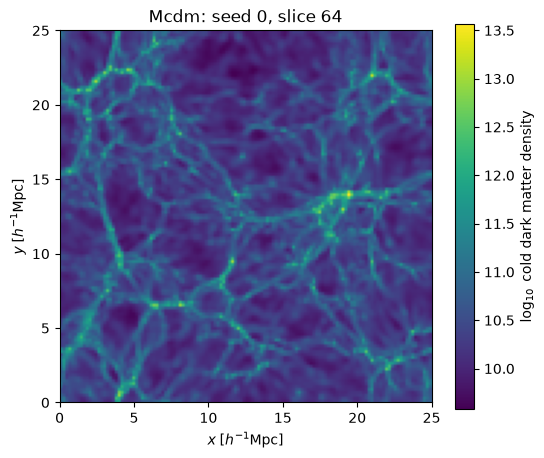

In [4]:
seed = 0
slice_number = 64
image = grids[seed, :, :, slice_number]

plt.figure(figsize=(6, 5))
plt.imshow(np.log10(image).T, origin="lower", extent=[0, 25, 0, 25])
plt.colorbar(label=r"$\log_{10}$ cold dark matter density")
plt.xlabel(r"$x\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$y\;[h^{-1}\mathrm{Mpc}]$")
plt.title(f"Mcdm: seed {seed}, slice {slice_number}")
plt.show()

## 1.5 Compare all five fields for two seeds

We now repeat the same indexing operation for seeds 0 and 1 and for every downloaded field. Each field column is assigned its own colour scale and physical unit. Within a column, the two seeds share identical colour limits, making differences caused by the initial conditions directly visible.

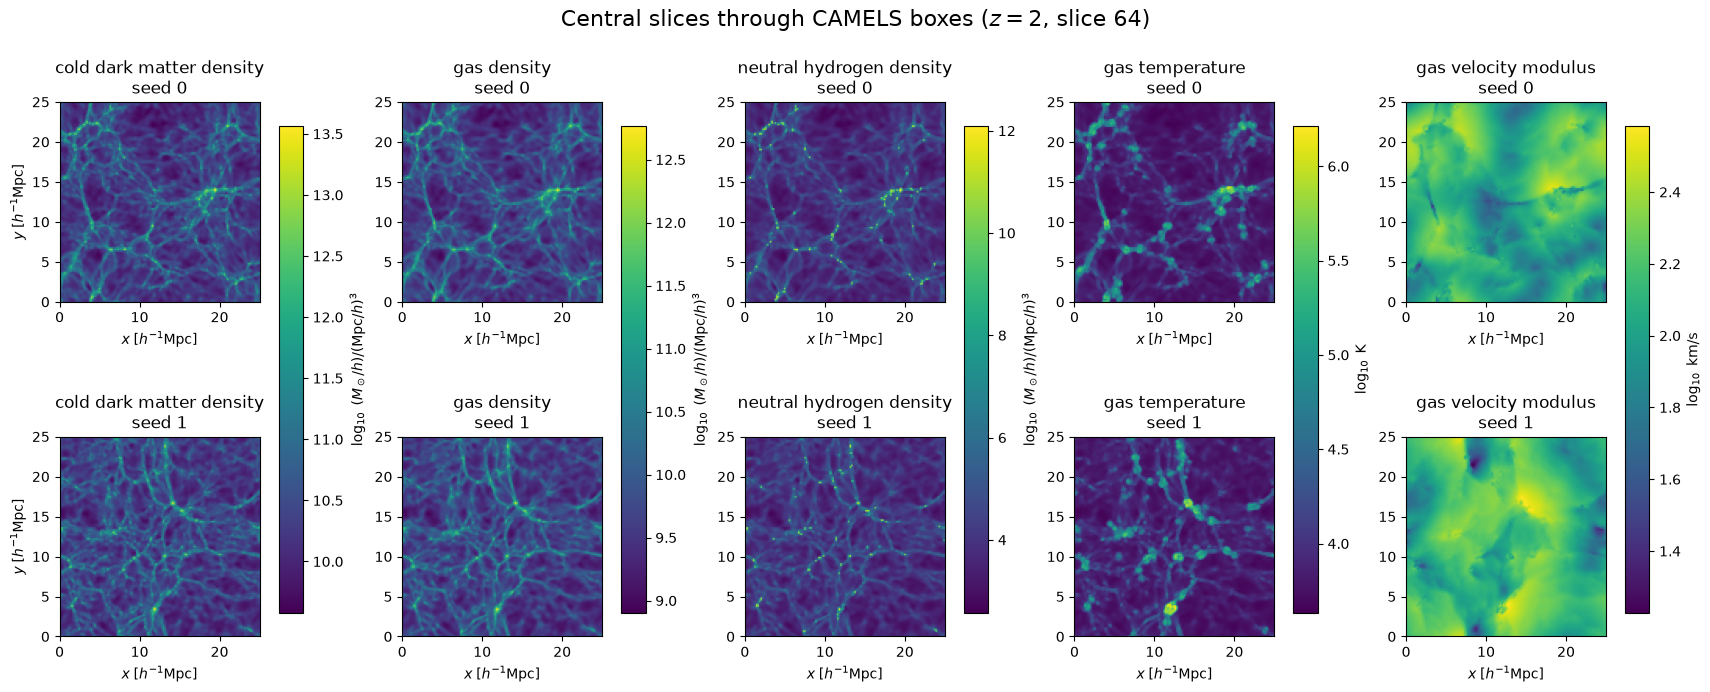

In [5]:
fields = {
    "Mcdm": ("cold dark matter density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "Mgas": ("gas density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "HI": ("neutral hydrogen density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "T": ("gas temperature", "K"),
    "Vgas": ("gas velocity modulus", "km/s"),
}

seeds = [0, 1]
slice_number = 64
fig, axes = plt.subplots(2, 5, figsize=(17, 7), constrained_layout=True)

for column, (field, (name, unit)) in enumerate(fields.items()):
    file = data_directory / f"Grids_{field}_IllustrisTNG_CV_128_z=2.0.npy"
    grids = np.load(file)

    images = []
    for seed in seeds:
        image = grids[seed, :, :, slice_number]
        images.append(np.log10(image).T)

    lower_limit = min(image.min() for image in images)
    upper_limit = max(image.max() for image in images)

    for row, seed in enumerate(seeds):
        plot = axes[row, column].imshow(
            images[row],
            origin="lower",
            extent=[0, 25, 0, 25],
            vmin=lower_limit,
            vmax=upper_limit,
        )
        axes[row, column].set_title(f"{name}\nseed {seed}")
        axes[row, column].set_xlabel(r"$x\;[h^{-1}\mathrm{Mpc}]$")
        if column == 0:
            axes[row, column].set_ylabel(r"$y\;[h^{-1}\mathrm{Mpc}]$")

    fig.colorbar(plot, ax=axes[:, column], shrink=0.75, label=rf"$\log_{{10}}$ {unit}")

fig.suptitle(f"Central slices through CAMELS boxes ($z=2$, slice {slice_number})", fontsize=16)
plt.show()

## 1.6 Save the comparison figure

The preceding Matplotlib figure remains referenced by fig and can therefore be written to disk without repeating the calculation.

In [6]:
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)
fig.savefig(output_directory / "CAMELS_slices_seeds_0_1.png", dpi=150, bbox_inches="tight")

### Exercises for exploring the volumes

1. Replace seeds with two other values between 0 and 26.
2. Change slice_number to any integer between 0 and 127.
3. Extract a plane perpendicular to a different axis. For example, grids[seed, 64, :, :] fixes the first spatial axis.
4. Remove np.log10(...) and examine why a linear colour scale suppresses much of the low-density structure.

The box is periodic: voxels on opposing faces are physical neighbours in the simulation.

# Part II — From a three-dimensional volume to a Lyα forest

Having established the geometry, indexing convention, and physical content of the grids, we now reduce the volume to a one-dimensional skewer. The analysis first introduces the atomic line profile and then converts the sampled CAMELS fields into a Lyα optical-depth and transmitted-flux spectrum.

## 2.1 Scientific scope and an important velocity limitation

The CAMELS Multifield Dataset (CMD) grids used here provide:

| File prefix | Stored field | Use in this notebook |
|---|---|---|
| HI | neutral-hydrogen mass density | converted to physical number density, $n_{\rm HI}$ |
| T | mass-weighted gas temperature in K | used for thermal broadening |
| Vgas | mass-weighted speed, $|\mathbf{v}_{\rm gas}|$, in km/s | plotted for context only |

Lyα redshift-space absorption requires the **signed component of peculiar velocity parallel to the sightline**, $v_\parallel$. CMD's Vgas field is instead a non-negative velocity modulus; it contains no directional information. We therefore set $v_\parallel=0$ in the optical-depth calculation. The generated spectrum includes Hubble flow and thermal broadening, but not peculiar-velocity distortions.

This is a pedagogical spectrum, not a precision synthetic observation. A complete calculation requires particle data or a vector velocity grid. See the [CMD paper](https://arxiv.org/abs/2109.10915) and [CAMELS data documentation](https://camels-multifield-dataset.readthedocs.io/en/latest/data.html) for the field definitions.

## 2.2 Import the additional scientific dependencies

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import special

from astropy import units as u
from astropy.constants import c, m_p, m_e, k_B
from astropy.cosmology import Planck18 as cosmo

## 2.3 Understanding the Voigt profile before sampling the box

An individual Lyα absorption feature is not infinitely narrow. Two physical mechanisms set its shape:

1. **Thermal (Doppler) broadening.** Hydrogen atoms have a distribution of line-of-sight thermal velocities. The resulting Gaussian core is controlled by the Doppler parameter

$$b=\sqrt{\frac{2k_{\rm B}T}{m_{\rm H}}}.$$

A larger $b$ corresponds to a broader thermal velocity distribution. Non-thermal or turbulent motions are sometimes included in an effective $b$, but our later CAMELS calculation uses thermal broadening only.

2. **Natural broadening.** The finite lifetime of the excited Lyα state gives a Lorentzian profile. It has narrow central structure but slowly declining damping wings.

The convolution of the Gaussian and Lorentzian profiles is the **Voigt profile**,

$$H(a,u)=\operatorname{Re}[w(u+ia)], \qquad u=\frac{\Delta v}{b}, \qquad a=\frac{\Gamma_\alpha c}{4\pi\nu_\alpha b},$$

where $w$ is the Faddeeva function. The optical depth of one cloud with neutral-hydrogen column density $N_{\rm HI}$ is

$$\tau(\Delta v)=N_{\rm HI}\frac{cI_\alpha}{\sqrt{\pi}b}H(a,u), \qquad F=\exp(-\tau).$$

Thus $b$ primarily controls the width of the core, while $N_{\rm HI}$ scales the amount of absorbing material. At sufficiently large $N_{\rm HI}$, the otherwise weak Lorentzian damping wings become visible.

In [8]:
I_alpha = 4.45e-18
lambda_alpha_cm = 1215.67e-8
gamma_alpha = 6.262e8
c_cms = c.to_value(u.cm / u.s)
nu_alpha = c_cms / lambda_alpha_cm


def single_cloud_tau(delta_velocity, N_HI, b):
    """Voigt optical depth for one cloud.

    delta_velocity and b are in km/s; N_HI is in cm^-2.
    """
    b_cms = b * 1e5
    a = gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * b_cms)
    u_voigt = delta_velocity / b
    H = np.real(special.wofz(u_voigt + 1j * a))
    cross_section = c_cms * I_alpha * H / (np.sqrt(np.pi) * b_cms)
    return N_HI * cross_section

### A visual experiment with mock absorbers

The upper-left panel below is a schematic point cloud of absorbers intersected by a mock sightline. Horizontal position indicates location along the skewer. A small vertical offset is added only so overlapping points can be seen; it is not a physical transverse coordinate. Marker size represents $N_{\rm HI}$ and colour represents $b$.

The other panels isolate the relevant effects. First we compare the peak-normalized Gaussian, Lorentzian, and Voigt shapes. We then hold $N_{\rm HI}$ fixed while changing $b$, and finally hold $b$ fixed while changing $N_{\rm HI}$. Separating the variables makes their roles easier to identify.

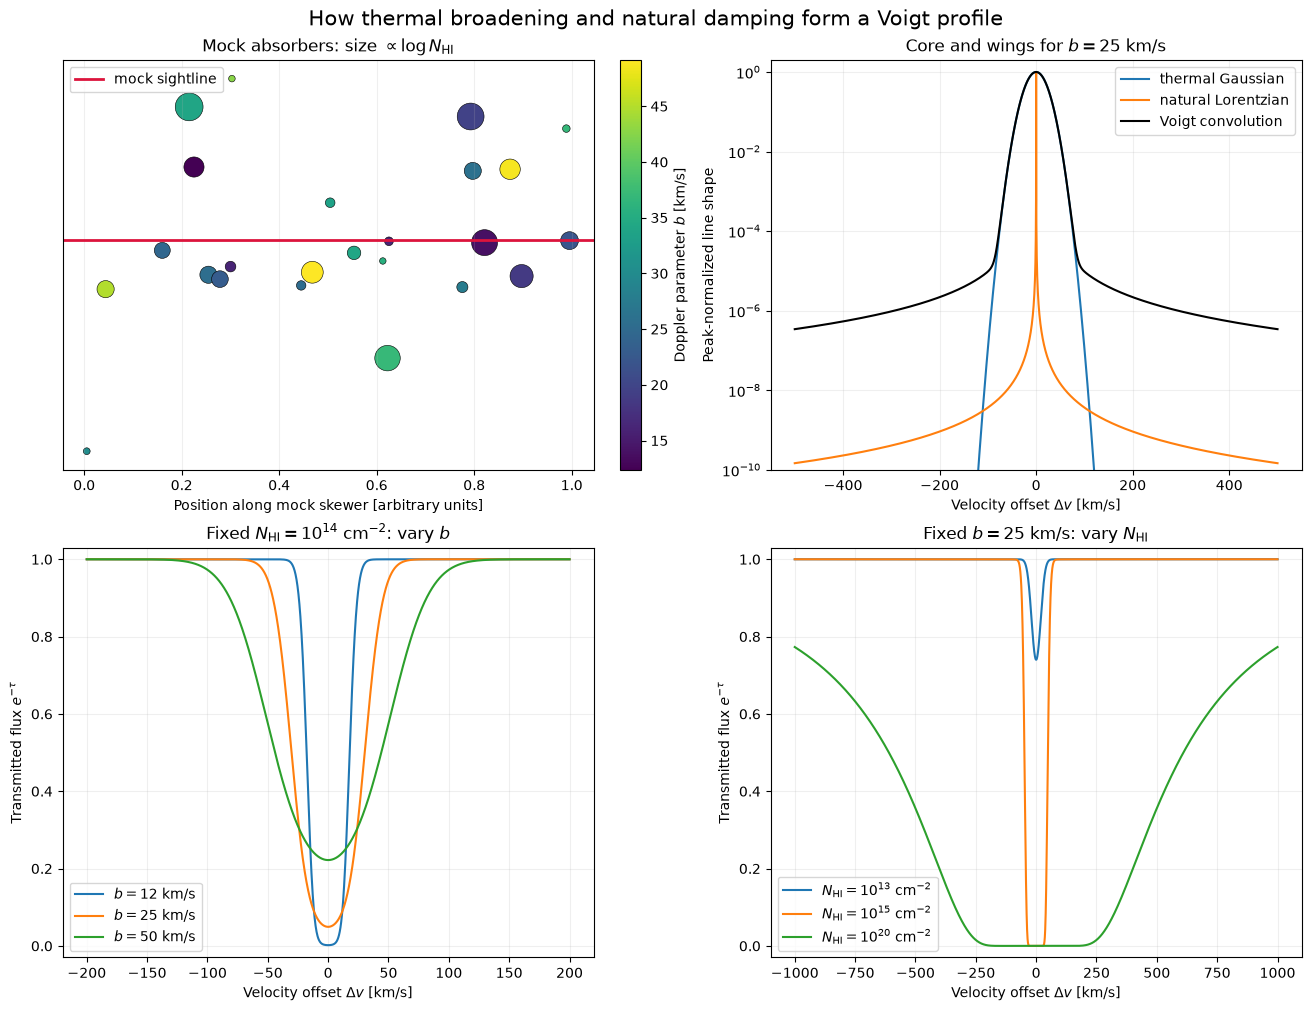

In [9]:
rng = np.random.default_rng(7)
mock_position = np.sort(rng.uniform(0.0, 1.0, 24))
mock_log_N_HI = rng.uniform(12.5, 20.0, 24)
mock_b = rng.uniform(10.0, 50.0, 24)
display_offset = rng.normal(0.0, 0.035, 24)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

# Mock population of absorbers along a sightline.
axes[0, 0].axhline(0.0, color="crimson", linewidth=2, label="mock sightline")
points = axes[0, 0].scatter(
    mock_position,
    display_offset,
    s=20 + 7 * (mock_log_N_HI - 12.0) ** 2,
    c=mock_b,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
)
axes[0, 0].set_xlabel("Position along mock skewer [arbitrary units]")
axes[0, 0].set_yticks([])
axes[0, 0].set_title(r"Mock absorbers: size $\propto \log N_{\rm HI}$")
axes[0, 0].legend(loc="upper left")
fig.colorbar(points, ax=axes[0, 0], label=r"Doppler parameter $b$ [km/s]")

# Gaussian, Lorentzian, and Voigt line shapes.
velocity_shape = np.linspace(-500.0, 500.0, 4001)
b_shape = 25.0
b_shape_cms = b_shape * 1e5
a_shape = gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * b_shape_cms)
u_shape = velocity_shape / b_shape
gaussian = np.exp(-u_shape**2)
lorentzian = a_shape**2 / (u_shape**2 + a_shape**2)
voigt = np.real(special.wofz(u_shape + 1j * a_shape))
voigt = voigt / voigt.max()

axes[0, 1].semilogy(velocity_shape, gaussian, label="thermal Gaussian")
axes[0, 1].semilogy(velocity_shape, lorentzian, label="natural Lorentzian")
axes[0, 1].semilogy(velocity_shape, voigt, color="black", label="Voigt convolution")
axes[0, 1].set_ylim(1e-10, 2.0)
axes[0, 1].set_xlabel(r"Velocity offset $\Delta v$ [km/s]")
axes[0, 1].set_ylabel("Peak-normalized line shape")
axes[0, 1].set_title(rf"Core and wings for $b={b_shape:.0f}$ km/s")
axes[0, 1].legend()

# Hold column density fixed and vary thermal width.
velocity_core = np.linspace(-200.0, 200.0, 2001)
fixed_N_HI = 1e14
for b_value in [12.0, 25.0, 50.0]:
    cloud_tau = single_cloud_tau(velocity_core, fixed_N_HI, b_value)
    axes[1, 0].plot(
        velocity_core,
        np.exp(-cloud_tau),
        label=rf"$b={b_value:.0f}$ km/s",
    )
axes[1, 0].set_xlabel(r"Velocity offset $\Delta v$ [km/s]")
axes[1, 0].set_ylabel(r"Transmitted flux $e^{-\tau}$")
axes[1, 0].set_title(r"Fixed $N_{\rm HI}=10^{14}\ {\rm cm}^{-2}$: vary $b$")
axes[1, 0].set_ylim(-0.03, 1.03)
axes[1, 0].legend()

# Hold thermal width fixed and vary column density.
velocity_wings = np.linspace(-1000.0, 1000.0, 4001)
fixed_b = 25.0
for N_HI_value in [1e13, 1e15, 1e20]:
    exponent = int(np.log10(N_HI_value))
    cloud_tau = single_cloud_tau(velocity_wings, N_HI_value, fixed_b)
    axes[1, 1].plot(
        velocity_wings,
        np.exp(-cloud_tau),
        label=rf"$N_{{\rm HI}}=10^{{{exponent}}}\ \mathrm{{cm}}^{{-2}}$",
    )
axes[1, 1].set_xlabel(r"Velocity offset $\Delta v$ [km/s]")
axes[1, 1].set_ylabel(r"Transmitted flux $e^{-\tau}$")
axes[1, 1].set_title(r"Fixed $b=25$ km/s: vary $N_{\rm HI}$")
axes[1, 1].set_ylim(-0.03, 1.03)
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.2)

fig.suptitle("How thermal broadening and natural damping form a Voigt profile", fontsize=15)
voigt_figure_directory = Path("figures")
voigt_figure_directory.mkdir(exist_ok=True)
fig.savefig(
    voigt_figure_directory / "Voigt_profile_mock_absorbers.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 2.4 Select a box and define a sightline

The sightline will run along the first spatial array axis, which we call $x$. Fixing one $y$ index and one $z$ index selects a straight, axis-aligned skewer. Changing the three integers below produces another spectrum.

In [10]:
data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

seed = 0
y_index = 64
z_index = 64

box_size = 25.0       # comoving Mpc/h
box_redshift = 2.0

## 2.5 Open the three fields required for the skewer

Each file has shape (27, 128, 128, 128): simulation number followed by the three spatial axes. The same array index in different field files refers to the same voxel in the same simulated universe. The read-only memory-map option avoids copying every simulation into memory; it does not change how NumPy indexing works.

In [11]:
HI_boxes = np.load(
    data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
T_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
Vgas_boxes = np.load(
    data_directory / "Grids_Vgas_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

print("HI shape:", HI_boxes.shape)
print("T shape:", T_boxes.shape)
print("Vgas shape:", Vgas_boxes.shape)

HI shape: (27, 128, 128, 128)
T shape: (27, 128, 128, 128)
Vgas shape: (27, 128, 128, 128)


## 2.6 Visualize the skewer within the simulation volume

The left panel is a geometric representation of the periodic simulation cube. The red line is the selected skewer. The right panel projects the neutral-hydrogen field along $x$ and marks the point where the skewer passes through the transverse $(y,z)$ plane.

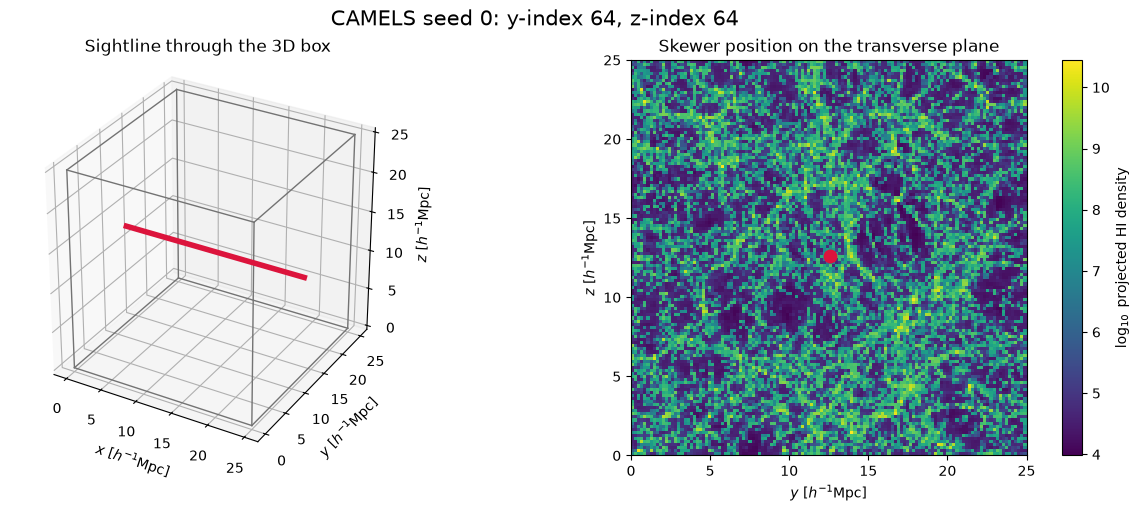

In [12]:
number_of_cells = HI_boxes.shape[1]
cell_size = box_size / number_of_cells
y_coordinate = (y_index + 0.5) * cell_size
z_coordinate = (z_index + 0.5) * cell_size

fig = plt.figure(figsize=(12, 5), constrained_layout=True)

ax = fig.add_subplot(1, 2, 1, projection="3d")
edges = [
    ((0, 0, 0), (box_size, 0, 0)),
    ((0, box_size, 0), (box_size, box_size, 0)),
    ((0, 0, box_size), (box_size, 0, box_size)),
    ((0, box_size, box_size), (box_size, box_size, box_size)),
    ((0, 0, 0), (0, box_size, 0)),
    ((box_size, 0, 0), (box_size, box_size, 0)),
    ((0, 0, box_size), (0, box_size, box_size)),
    ((box_size, 0, box_size), (box_size, box_size, box_size)),
    ((0, 0, 0), (0, 0, box_size)),
    ((box_size, 0, 0), (box_size, 0, box_size)),
    ((0, box_size, 0), (0, box_size, box_size)),
    ((box_size, box_size, 0), (box_size, box_size, box_size)),
]

for start, end in edges:
    ax.plot(*zip(start, end), color="0.45", linewidth=1)

ax.plot(
    [0, box_size],
    [y_coordinate, y_coordinate],
    [z_coordinate, z_coordinate],
    color="crimson",
    linewidth=4,
)
ax.set_xlabel(r"$x\ [h^{-1}{\rm Mpc}]$")
ax.set_ylabel(r"$y\ [h^{-1}{\rm Mpc}]$")
ax.set_zlabel(r"$z\ [h^{-1}{\rm Mpc}]$")
ax.set_title("Sightline through the 3D box")
ax.set_box_aspect((1, 1, 1))

ax = fig.add_subplot(1, 2, 2)
HI_projection = np.log10(HI_boxes[seed].mean(axis=0)).T
image = ax.imshow(
    HI_projection,
    origin="lower",
    extent=[0, box_size, 0, box_size],
)
ax.plot(y_coordinate, z_coordinate, "o", color="crimson", markersize=9)
ax.set_xlabel(r"$y\ [h^{-1}{\rm Mpc}]$")
ax.set_ylabel(r"$z\ [h^{-1}{\rm Mpc}]$")
ax.set_title("Skewer position on the transverse plane")
fig.colorbar(image, ax=ax, label=r"$\log_{10}$ projected HI density")

fig.suptitle(f"CAMELS seed {seed}: y-index {y_index}, z-index {z_index}", fontsize=15)
fig.savefig(
    output_directory / f"CAMELS_skewer_geometry_seed_{seed}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 2.7 Extract the one-dimensional physical fields

Cell centres are used as absorber positions,

$$x_i=\left(i+\frac{1}{2}\right)\Delta x, \qquad \Delta x=\frac{L}{N}.$$

Here $\Delta x=25/128\simeq0.195\ h^{-1}{\rm Mpc}$. Direct indexing extracts the corresponding HI density, temperature, and available gas-speed values.

In [13]:
x_abs = (np.arange(number_of_cells) + 0.5) * cell_size

HI_grid_density = HI_boxes[seed, :, y_index, z_index].copy()
temperature = T_boxes[seed, :, y_index, z_index].copy()
gas_speed = Vgas_boxes[seed, :, y_index, z_index].copy()

print("Number of absorber cells:", len(x_abs))
print("Comoving cell width (Mpc/h):", cell_size)
print("Temperature range (K):", temperature.min(), temperature.max())
print("Gas-speed range (km/s):", gas_speed.min(), gas_speed.max())

Number of absorber cells: 128
Comoving cell width (Mpc/h): 0.1953125
Temperature range (K): 4882.742 137568.6
Gas-speed range (km/s): 36.269924 215.04622


## 2.8 Convert comoving position to absorber redshift

The box is treated as a short comoving segment centred on $z_{\rm box}=2$. For a small interval, the comoving radial-distance relation $d\chi=c\,dz/H(z)$ gives

$$z_i\simeq z_{\rm box}+\frac{H(z_{\rm box})}{c}\,\frac{x_i-L/2}{h}.$$

The factor $1/h$ converts Mpc/$h$ to Mpc. This linear approximation is adequate across one 25 Mpc/$h$ box; it spans only about $\Delta z=0.025$. Following the supplied routine, this notebook adopts Planck18. Its $h=0.6766$ differs slightly from the fixed CMD value near 0.67; precision work should use the exact simulation-header cosmology.

In [14]:
distance_from_box_centre_Mpc = (x_abs - box_size / 2.0) / cosmo.h
H_z = cosmo.H(box_redshift).to_value(u.km / u.s / u.Mpc)
c_kms = c.to_value(u.km / u.s)

z_abs = box_redshift + H_z * distance_from_box_centre_Mpc / c_kms
z_eval = z_abs.copy()

print("Planck18 h:", cosmo.h)
print("Absorber-redshift range:", z_abs.min(), z_abs.max())

Planck18 h: 0.6766
Absorber-redshift range: 1.9875242326939306 2.0124757673060696


## 2.9 Convert HI mass density to physical number density

The grid stores neutral-hydrogen mass density in

$$\frac{M_\odot/h}{({\rm Mpc}/h)^3}.$$

Because the CAMELS box coordinates and voxel volume are comoving, the physical density at absorber redshift $z_i$ is

$$\rho_{{\rm HI,phys},i}=(1+z_i)^3\rho_{{\rm HI,com},i}.$$

Finally,

$$n_{{\rm HI},i}=\frac{\rho_{{\rm HI,phys},i}}{m_{\rm H}}, \qquad m_{\rm H}\simeq m_p+m_e.$$

Astropy performs the solar-mass/Mpc to g/cm conversion explicitly below. Temperature is already stored in kelvin and needs no unit rescaling. The CMD temperature is mass-weighted within each voxel, another approximation when it is assigned to all neutral hydrogen in that voxel.

In [15]:
CMD_density_unit = (u.Msun / cosmo.h) / (u.Mpc / cosmo.h) ** 3

rho_HI_comoving = (HI_grid_density * CMD_density_unit).to_value(u.g / u.cm**3)
rho_HI_physical = rho_HI_comoving * (1.0 + z_abs) ** 3
hydrogen_mass = (m_p + m_e).to_value(u.g)
n_HI = rho_HI_physical / hydrogen_mass

# A signed line-of-sight velocity is unavailable in CMD, so use zero.
v_pec = np.zeros_like(gas_speed)

print("Physical n_HI range (cm^-3):", n_HI.min(), n_HI.max())

Physical n_HI range (cm^-3): 4.32168075283831e-13 3.3975669326743267e-09


## 2.10 Formulate the Lyα optical depth

For absorber cell $i$, the thermal Doppler parameter is

$$b_i=\sqrt{\frac{2k_{\rm B}T_i}{m_{\rm H}}}.$$

Natural and thermal broadening are combined through the Voigt function

$$H(a_i,u_{ij})=\operatorname{Re}\left[w(u_{ij}+ia_i)\right],$$

where $w$ is the Faddeeva function and

$$a_i=\frac{\Gamma_{\alpha}c}{4\pi\nu_{\alpha}b_i},$$

$$u_{ij}=\frac{c(z_i-z_j)}{b_i(1+z_j)}+\frac{v_{\parallel,i}}{b_i}.$$

The discretized optical depth evaluated at redshift $z_j$ is

$$\tau(z_j)=\sum_i\frac{c\,I_{\alpha}}{\sqrt{\pi}}\frac{\Delta x_{\rm com}\,n_{{\rm HI},i}}{b_i(1+z_i)}H(a_i,u_{ij}).$$

The factor $(1+z_i)^{-1}$ converts the comoving path element to a proper path element. The constants $I_{\alpha}=4.45\times10^{-18}$, $\lambda_{\alpha}=1215.67$ Å, and $\Gamma_{\alpha}=6.262\times10^8\ {\rm s}^{-1}$ are those used by the supplied implementation.

In [16]:
def tau(x_abs, z_abs, z_eval, n_HI, T, v_pec):
    """Compute Ly-alpha optical depth at the evaluation redshifts.

    x_abs is in comoving Mpc/h; n_HI is in cm^-3; T is in K;
    and v_pec is the signed line-of-sight velocity in km/s.
    The last three inputs have shape (number of skewers, number of cells).
    """
    I = 4.45e-18
    x_cm = u.Mpc.to(u.cm) * x_abs / cosmo.h
    lambda_lu = 1215.67e-8
    nu_lu = c.to(u.cm / u.s).value / lambda_lu
    gamma_ul = 6.262e8
    m_H = (m_p + m_e).to(u.g).value
    c_cms = c.to(u.cm / u.s).value

    b = np.sqrt(2.0 * k_B.to(u.erg / u.K).value * T / m_H)
    dx = np.mean(np.diff(x_cm))

    term1 = (
        c_cms
        * I
        / np.sqrt(np.pi)
        * dx
        * n_HI
        / (b * (1.0 + z_abs[None, :]))
    )

    z_abs_exp = z_abs[None, :, None]
    z_eval_exp = z_eval[None, None, :]
    b_exp = b[:, :, None]
    v_pec_exp = v_pec[:, :, None]

    term2 = np.real(
        special.wofz(
            1j * gamma_ul * c_cms / (4.0 * np.pi * nu_lu * b_exp)
            + c_cms * (z_abs_exp - z_eval_exp)
            / (b_exp * (1.0 + z_eval_exp))
            + v_pec_exp * 1e5 / b_exp
        )
    )

    return np.sum(term1[:, :, None] * term2, axis=1)

## 2.11 Generate the Lyα forest

The routine accepts a leading sightline axis, so the one-dimensional fields are temporarily given shape (1, 128). The continuum-normalized transmitted flux is

$$F(z)=\exp[-\tau(z)].$$

In [17]:
optical_depth = tau(
    x_abs,
    z_abs,
    z_eval,
    n_HI[None, :],
    temperature[None, :],
    v_pec[None, :],
)[0]

transmitted_flux = np.exp(-optical_depth)

print("Optical-depth range:", optical_depth.min(), optical_depth.max())
print("Mean transmitted flux (not rescaled):", transmitted_flux.mean())

Optical-depth range: 0.011016663810335007 31.249691174325765
Mean transmitted flux (not rescaled): 0.6956654994490852


## 2.12 Plot the input fields and the resulting Lyα forest

All panels share the same comoving coordinate, so density and temperature structures can be compared directly with absorption features. In the velocity panel, the solid line is the signed velocity actually supplied to the calculation; the dashed line is CMD's available speed and is shown only to make the missing information explicit.

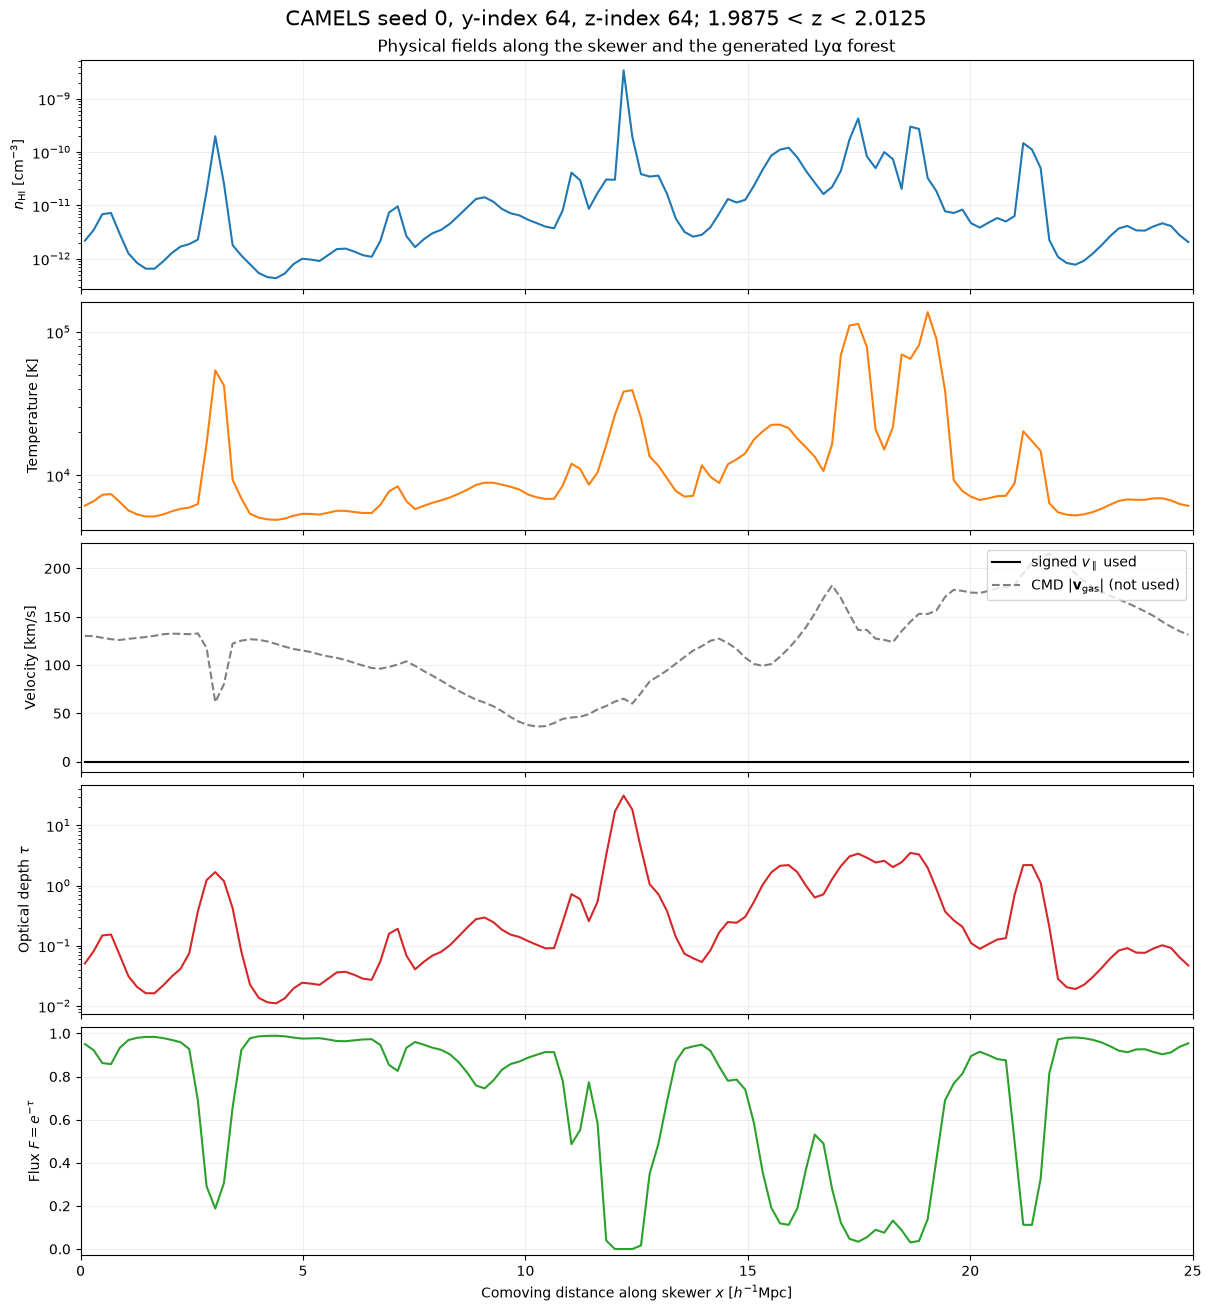

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True, constrained_layout=True)

axes[0].semilogy(x_abs, n_HI, color="tab:blue")
axes[0].set_ylabel(r"$n_{\rm HI}\ [{\rm cm}^{-3}]$")
axes[0].set_title("Physical fields along the skewer and the generated Lyα forest")

axes[1].semilogy(x_abs, temperature, color="tab:orange")
axes[1].set_ylabel("Temperature [K]")

axes[2].plot(x_abs, v_pec, color="black", label=r"signed $v_\parallel$ used")
axes[2].plot(x_abs, gas_speed, "--", color="0.5", label=r"CMD $|\mathbf{v}_{\rm gas}|$ (not used)")
axes[2].set_ylabel("Velocity [km/s]")
axes[2].legend(loc="upper right")

axes[3].semilogy(x_abs, optical_depth, color="tab:red")
axes[3].set_ylabel(r"Optical depth $\tau$")

axes[4].plot(x_abs, transmitted_flux, color="tab:green")
axes[4].set_ylabel(r"Flux $F=e^{-\tau}$")
axes[4].set_xlabel(r"Comoving distance along skewer $x\ [h^{-1}{\rm Mpc}]$")
axes[4].set_ylim(-0.03, 1.03)

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0, box_size)

fig.suptitle(
    f"CAMELS seed {seed}, y-index {y_index}, z-index {z_index}; "
    f"{z_abs.min():.4f} < z < {z_abs.max():.4f}",
    fontsize=15,
)
fig.savefig(
    output_directory / f"CAMELS_Lya_forest_seed_{seed}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 2.13 Interpretation and limitations

- Larger $n_{\rm HI}$ generally produces larger optical depth and lower transmitted flux.
- Temperature controls the Doppler width: hotter cells distribute their absorption over a broader velocity interval.
- The peculiar-velocity term is zero here because a signed velocity component is unavailable. The grey speed curve must not be substituted for $v_\parallel$.
- Each voxel is about $0.195\ h^{-1}{\rm Mpc}$ wide. Sub-voxel gas structure is therefore absent, and the mass-weighted voxel temperature is only an approximate temperature for the neutral absorber.
- One snapshot is used across the short redshift interval (the snapshot approximation).
- The flux has not been adjusted to an observed mean flux and has no continuum, noise, or instrumental line-spread function.

To make another skewer, change seed, y_index, or z_index near the beginning and rerun the notebook.